# Phân tích factorial: success rate của LLM planning phụ thuộc method, model và prompt

Phân tích success rate trên bài toán Blocks World theo ba yếu tố:

- **Method** — `llm_only` so với `llm_planner`
- **Model** — Qwen 2.5 3B, Qwen 2.5 7B, Llama 3.1 8B
- **Prompt** — `basic` so với `detailed`

## Thiết lập chung


In [31]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT_DIR = Path("..")
SRC_DIR = ROOT_DIR / "src"
sys.path.insert(0, str(SRC_DIR))

import viz_analysis as viz
from viz_analysis import (
    CONFIG_COLORS,
    DIFFICULTY_ORDER,
    METHOD_COLORS,
    METHOD_LABELS,
    METHOD_ORDER,
    MODEL_LABELS,
    MODEL_ORDER,
    PROMPT_LABELS,
    PROMPT_ORDER,
)


## 1. Load dữ liệu


In [32]:
df, load_report = viz.load_all_metrics(ROOT_DIR)
display(load_report)

duplicate_count = int(
    df.duplicated(["model", "prompt_variant", "method", "id"]).sum()
)
loaded_count = int((load_report["status"] == "loaded").sum())

display(Markdown(
    f"**Đã load {loaded_count}/{len(viz.RESULT_SPECS)} biến thể, "
    f"tổng cộng {len(df):,} dòng.** "
    f"Số khóa `(model, prompt, method, id)` bị trùng: **{duplicate_count}**."
))


,model,prompt_variant,path,status,rows
0,qwen2.5-3b,basic,..\results\qwen2.5-3b-instruct\basic\metrics.csv,loaded,80
1,qwen2.5-3b,detailed,..\results\qwen2.5-3b-instruct\detailed\metric...,loaded,80
2,qwen2.5-7b,basic,..\results\qwen2.5-7b-instruct\basic\metrics.csv,loaded,80
3,qwen2.5-7b,detailed,..\results\qwen2.5-7b-instruct\detailed\metric...,loaded,80
4,llama3.1-8b,basic,..\results\llama3.1-8b\basic\metrics.csv,loaded,80
5,llama3.1-8b,detailed,..\results\llama3.1-8b\detailed\metrics.csv,loaded,80


**Đã load 6/6 biến thể, tổng cộng 480 dòng.** Số khóa `(model, prompt, method, id)` bị trùng: **0**.

## 2. Kiểm tra cân bằng thiết kế



In [33]:
full_config_index = pd.MultiIndex.from_product(
    [MODEL_ORDER, PROMPT_ORDER],
    names=["model", "prompt_variant"],
)
full_design_columns = pd.MultiIndex.from_product(
    [METHOD_ORDER, DIFFICULTY_ORDER],
    names=["method", "difficulty"],
)

count_series = df.groupby(
    ["model", "prompt_variant", "method", "difficulty"],
    observed=True,
).size()
count_pivot = (
    count_series.unstack(["method", "difficulty"])
    .reindex(index=full_config_index, columns=full_design_columns)
    .fillna(0)
    .astype(int)
)

expected_by_difficulty = (
    df.groupby("difficulty", observed=True)["id"]
    .nunique()
    .reindex(DIFFICULTY_ORDER)
    .fillna(0)
    .astype(int)
)
expected_matrix = pd.DataFrame(
    {
        column: expected_by_difficulty[column[1]]
        for column in full_design_columns
    },
    index=full_config_index,
)
imbalance_mask = count_pivot.ne(expected_matrix)


display(viz.style_design_counts(count_pivot, imbalance_mask))

bad_cells = int(imbalance_mask.to_numpy().sum())
design_message = (
    "Thiết kế đầy đủ và cân bằng theo từng mức difficulty."
    if bad_cells == 0
    else f"Có {bad_cells} ô lệch số bài kỳ vọng; các ô này được tô đỏ."
)
display(Markdown(
    f"**Kết quả kiểm tra:** {design_message} "
    f"Số bài kỳ vọng theo difficulty: "
    f"`easy={expected_by_difficulty['easy']}`, "
    f"`medium={expected_by_difficulty['medium']}`, "
    f"`hard={expected_by_difficulty['hard']}`."
))


**Kết quả kiểm tra:** Thiết kế đầy đủ và cân bằng theo từng mức difficulty. Số bài kỳ vọng theo difficulty: `easy=10`, `medium=15`, `hard=15`.

## 3. Toàn cảnh success rate theo cả ba yếu tố

Bảng và heatmap tổng hợp success rate của toàn bộ cấu hình trong một góc nhìn: mỗi hàng là một cặp `(model, prompt)`, mỗi cột là một method. Số liệu biến thiên theo chiều dọc cho thấy ảnh hưởng của model và prompt, chênh lệch giữa hai cột cho thấy ảnh hưởng của method.

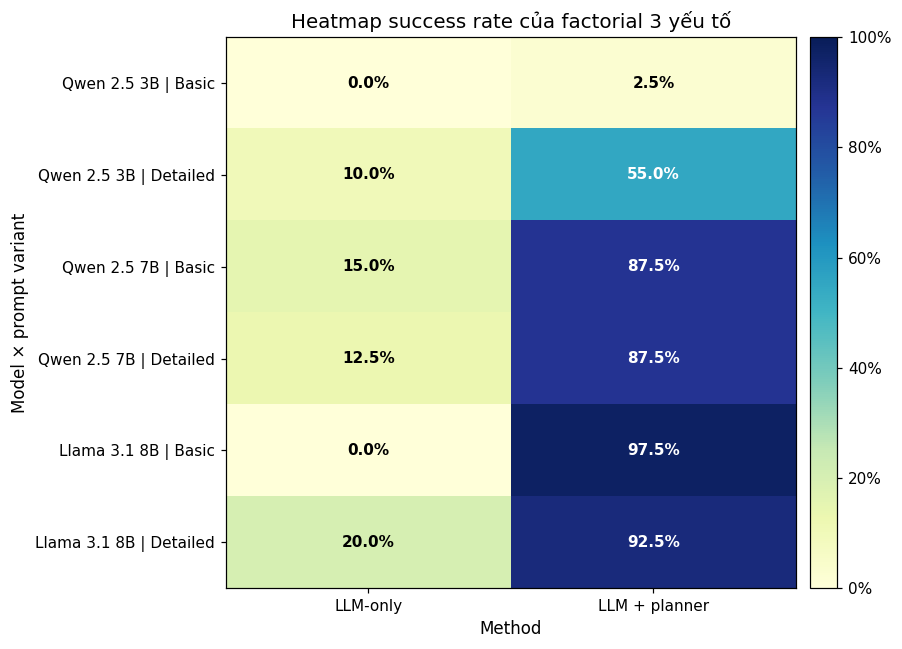

Trên bảng trung tâm, success rate trải từ **0.0%** đến **97.5%**. Biên độ **+97.5 điểm %** cho thấy kết quả không thể được mô tả chỉ bằng một cấu hình chung.

In [34]:
central_table = (
    df.groupby(["model", "prompt_variant", "method"], observed=True)["success"]
    .mean()
    .unstack("method")
    .reindex(index=full_config_index, columns=METHOD_ORDER)
)

display(
    viz.style_percent_table(
        central_table,
        "Success rate theo model × prompt × method",
    )
)

fig = viz.plot_central_heatmap(central_table)
plt.show()

finite_values = central_table.stack().dropna()
display(Markdown(
    f"Trên bảng trung tâm, success rate trải từ **{finite_values.min():.1%}** "
    f"đến **{finite_values.max():.1%}**. Biên độ "
    f"**{viz.pp(finite_values.max() - finite_values.min())}** "
    "cho thấy kết quả không thể được mô tả chỉ bằng một cấu hình chung."
))


Heatmap cho thấy **method là yếu tố chi phối mạnh nhất**: cột `LLM + planner` gần như luôn vượt trội so với `LLM-only`, vốn không bao giờ quá 20% ở mọi cấu hình. Điều này khẳng định LLM thuần khó tự sinh chuỗi hành động hợp lệ cho Blocks World, và việc bổ sung symbolic planner là cải thiện quyết định nhất.

Tuy nhiên cột planner **không đồng đều** — nó dao động từ 2.5% đến 97.5% tùy model và prompt, cho thấy planner không phải "viên đạn bạc": nó chỉ giải được khi LLM sinh JSON parse được, nên vẫn lệ thuộc vào chất lượng đầu vào. Đáng chú ý nhất là vai trò của prompt mang tính **điều kiện**: với model yếu (Qwen 2.5 3B), prompt `detailed` là yếu tố cứu cánh, kéo success rate của nhánh planner từ 2.5% lên 55% (+52.5 điểm %); nhưng với các model mạnh hơn (7B, 8B), prompt `detailed` gần như không đổi (7B giữ nguyên 87.5%) hoặc thậm chí làm giảm nhẹ (Llama 8B từ 97.5% xuống 92.5%). Đây là quy luật quen thuộc: prompt engineering hữu ích nhất cho model yếu, còn với model đã đủ mạnh thì lợi ích bão hòa hoặc phản tác dụng.

Cấu hình tốt nhất là **Llama 3.1 8B + Basic + planner (97.5%)** — và việc nó vượt cả phiên bản Detailed của chính nó là bằng chứng trực tiếp cho luận điểm: kết quả không phụ thuộc một yếu tố đơn lẻ, mà là sự kết hợp giữa model, prompt và method. Biên độ 0.0%–97.5% trên cùng một bài toán cho thấy lựa chọn cấu hình quan trọng đến mức nào.

## 4. Main effects


### 4a. Main effect của method


,success_rate,n
method,,
llm_only,9.6%,240
llm_planner,70.4%,240


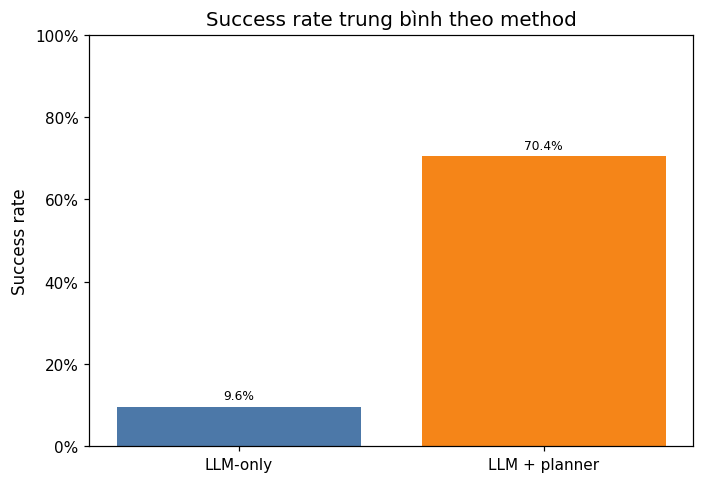

Method tốt hơn khi gộp toàn bộ thí nghiệm là **LLM + planner**. Khoảng cách giữa hai method là **+60.8 điểm %**.

In [35]:
method_effect = (
    df.groupby("method", observed=True)["success"]
    .agg(success_rate="mean", n="size")
    .reindex(METHOD_ORDER)
)
display(viz.style_method_effect(method_effect))

fig = viz.plot_method_effect(method_effect)
plt.show()

method_gap = method_effect["success_rate"].max() - method_effect["success_rate"].min()
best_method = method_effect["success_rate"].idxmax()
display(Markdown(
    f"Method tốt hơn khi gộp toàn bộ thí nghiệm là "
    f"**{METHOD_LABELS[best_method]}**. "
    f"Khoảng cách giữa hai method là **{viz.pp(method_gap)}**."
))


### 4b. Main effect của model


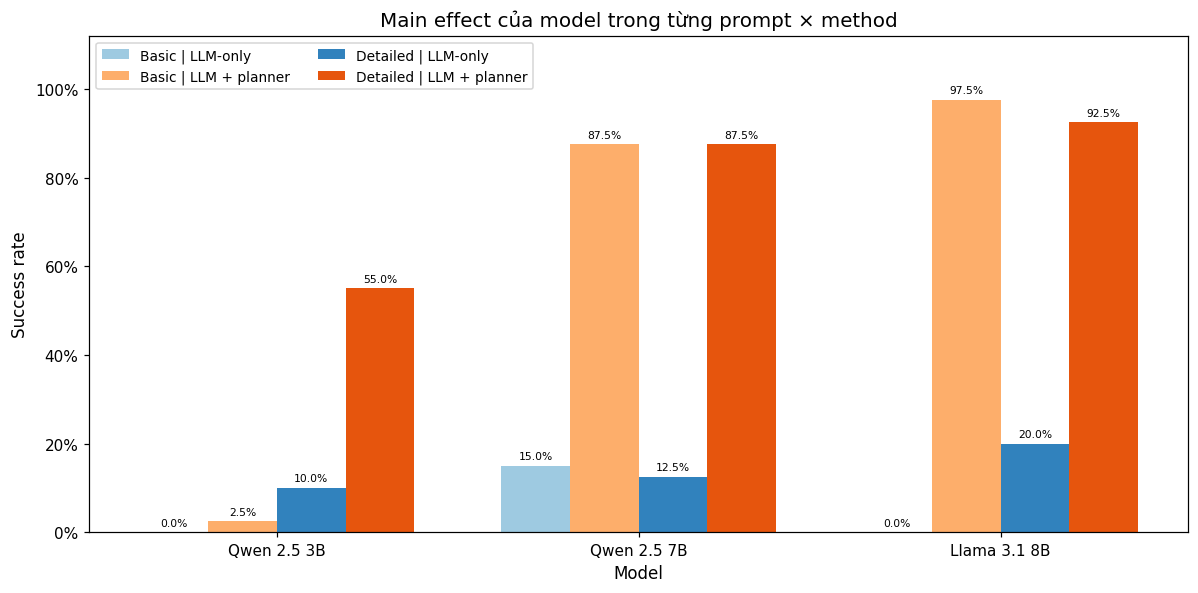

Model có success rate trung bình cao nhất là **Llama 3.1 8B (52.5%)**. Chênh lệch model cao nhất–thấp nhất là **+35.6 điểm %**.

In [36]:
model_columns = pd.MultiIndex.from_product(
    [PROMPT_ORDER, METHOD_ORDER],
    names=["prompt_variant", "method"],
)
model_effect = (
    df.groupby(["model", "prompt_variant", "method"], observed=True)["success"]
    .mean()
    .unstack(["prompt_variant", "method"])
    .reindex(index=MODEL_ORDER, columns=model_columns)
)
display(
    viz.style_percent_table(
        model_effect,
        "Success rate theo model, giữ riêng prompt × method",
    )
)

fig = viz.plot_model_effect(model_effect)
plt.show()

model_overall = (
    df.groupby("model", observed=True)["success"].mean().reindex(MODEL_ORDER)
)
best_model = model_overall.idxmax()
model_spread = model_overall.max() - model_overall.min()
display(Markdown(
    f"Model có success rate trung bình cao nhất là **{MODEL_LABELS[best_model]} "
    f"({model_overall[best_model]:.1%})**. Chênh lệch model cao nhất–thấp nhất là "
    f"**{viz.pp(model_spread)}**."
))


### 4c. Main effect của prompt variant


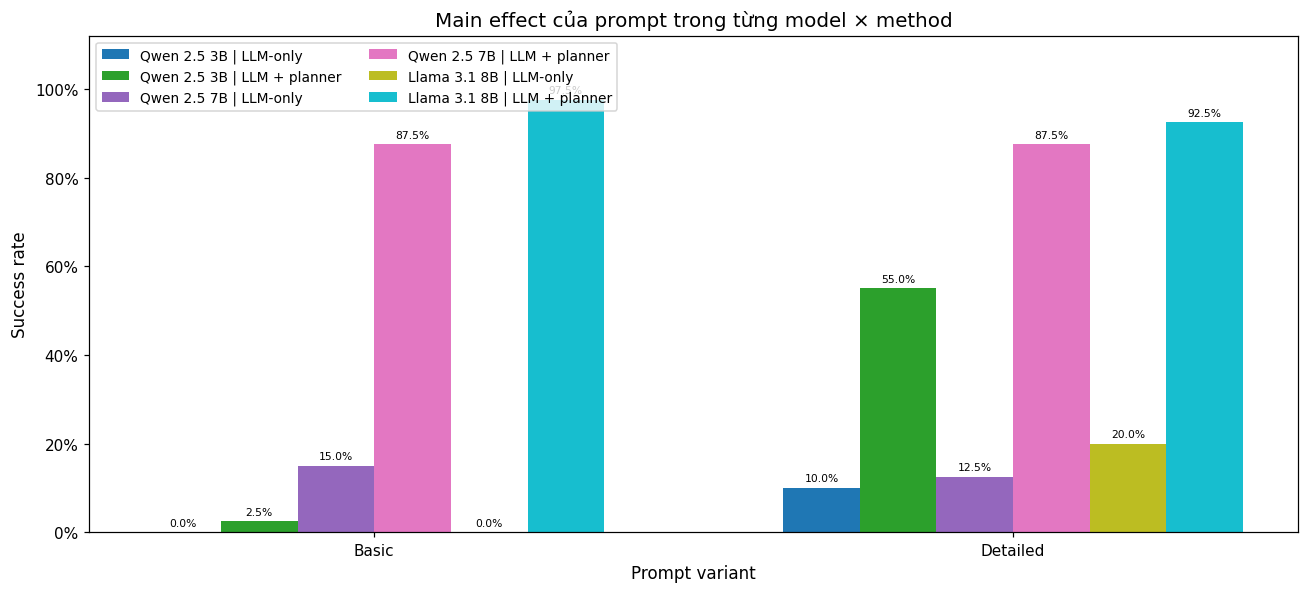

Success rate trung bình của Basic là **33.8%**, của Detailed là **46.2%**; thay đổi trung bình do prompt là **+12.5 điểm %**.

In [37]:
prompt_columns = pd.MultiIndex.from_product(
    [MODEL_ORDER, METHOD_ORDER],
    names=["model", "method"],
)
prompt_effect = (
    df.groupby(["prompt_variant", "model", "method"], observed=True)["success"]
    .mean()
    .unstack(["model", "method"])
    .reindex(index=PROMPT_ORDER, columns=prompt_columns)
)
display(
    viz.style_percent_table(
        prompt_effect,
        "Success rate theo prompt, giữ riêng model × method",
    )
)

fig = viz.plot_prompt_effect(prompt_effect)
plt.show()

prompt_overall = (
    df.groupby("prompt_variant", observed=True)["success"]
    .mean()
    .reindex(PROMPT_ORDER)
)
overall_prompt_delta = prompt_overall["detailed"] - prompt_overall["basic"]
display(Markdown(
    f"Success rate trung bình của Basic là **{prompt_overall['basic']:.1%}**, "
    f"của Detailed là **{prompt_overall['detailed']:.1%}**; "
    f"thay đổi trung bình do prompt là **{viz.pp(overall_prompt_delta)}**."
))


## 5. Interaction analysis


### 5a. Prompt × method


prompt_variant,basic,detailed,delta_detailed_minus_basic
method,,,
llm_only,5.0%,14.2%,9.2%
llm_planner,62.5%,78.3%,15.8%


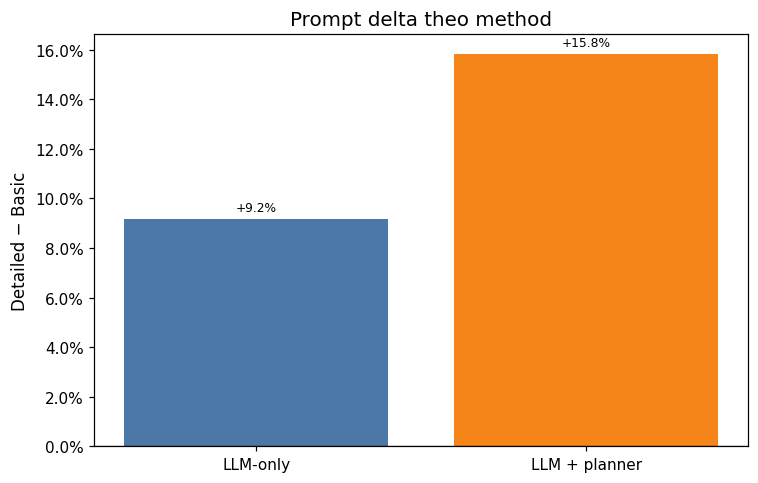

Detailed giúp nhiều nhất cho **LLM + planner** với delta **+15.8 điểm %**. Delta của method còn lại là **+9.2 điểm %**.

In [38]:
prompt_method_rates = (
    df.groupby(["method", "prompt_variant"], observed=True)["success"]
    .mean()
    .unstack("prompt_variant")
    .reindex(index=METHOD_ORDER, columns=PROMPT_ORDER)
)
delta_method = prompt_method_rates["detailed"] - prompt_method_rates["basic"]

interaction_method_table = prompt_method_rates.copy()
interaction_method_table["delta_detailed_minus_basic"] = delta_method
display(
    viz.style_percent_table(
        interaction_method_table,
        "Interaction Prompt × method",
    )
)

fig = viz.plot_prompt_delta_by_method(delta_method)
plt.show()

strongest_prompt_method = delta_method.idxmax()
display(Markdown(
    f"Detailed giúp nhiều nhất cho **{METHOD_LABELS[strongest_prompt_method]}** "
    f"với delta **{viz.pp(delta_method[strongest_prompt_method])}**. "
    f"Delta của method còn lại là "
    f"**{viz.pp(delta_method.drop(strongest_prompt_method).iloc[0])}**."
))


### 5b. Prompt × model

method,llm_only,llm_planner
model,,
qwen2.5-3b,10.0%,52.5%
qwen2.5-7b,-2.5%,0.0%
llama3.1-8b,20.0%,-5.0%


prompt_variant,basic,detailed,delta_detailed_minus_basic
model,,,
qwen2.5-3b,1.2%,32.5%,31.2%
qwen2.5-7b,51.2%,50.0%,-1.2%
llama3.1-8b,48.8%,56.2%,7.5%


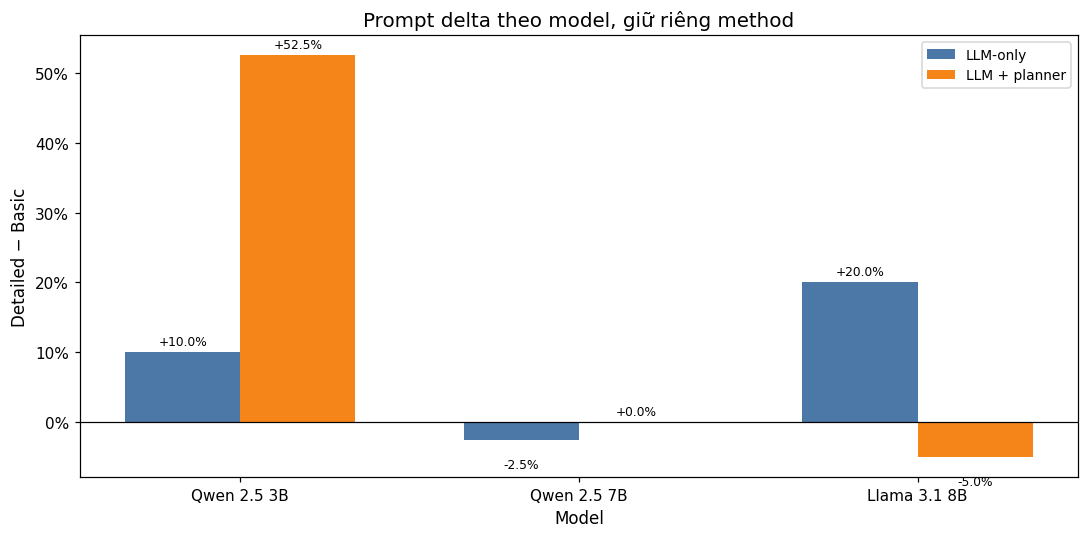

Model hưởng lợi trung bình nhiều nhất từ Detailed là **Qwen 2.5 3B (+31.2 điểm %)**. Delta của Qwen 2.5 3B (**+31.2 điểm %**) lớn hơn delta của Llama 3.1 8B (**+7.5 điểm %**).

In [39]:
prompt_model_method_rates = (
    df.groupby(["model", "method", "prompt_variant"], observed=True)["success"]
    .mean()
    .unstack("prompt_variant")
)
delta_model_method = (
    prompt_model_method_rates["detailed"] - prompt_model_method_rates["basic"]
).unstack("method").reindex(index=MODEL_ORDER, columns=METHOD_ORDER)

prompt_model_rates = (
    df.groupby(["model", "prompt_variant"], observed=True)["success"]
    .mean()
    .unstack("prompt_variant")
    .reindex(index=MODEL_ORDER, columns=PROMPT_ORDER)
)
delta_model = prompt_model_rates["detailed"] - prompt_model_rates["basic"]
model_interaction_table = prompt_model_rates.copy()
model_interaction_table["delta_detailed_minus_basic"] = delta_model

display(
    viz.style_percent_table(
        delta_model_method,
        "Prompt delta theo model × method",
    )
)
display(
    viz.style_percent_table(
        model_interaction_table,
        "Prompt × model, gộp trên method",
    )
)

fig = viz.plot_prompt_delta_by_model(delta_model_method)
plt.show()

best_prompt_model = delta_model.idxmax()
qwen3_delta = delta_model.get("qwen2.5-3b", np.nan)
llama8_delta = delta_model.get("llama3.1-8b", np.nan)
comparison = (
    "lớn hơn" if qwen3_delta > llama8_delta
    else "nhỏ hơn" if qwen3_delta < llama8_delta
    else "bằng"
)
display(Markdown(
    f"Model hưởng lợi trung bình nhiều nhất từ Detailed là "
    f"**{MODEL_LABELS[best_prompt_model]} "
    f"({viz.pp(delta_model[best_prompt_model])})**. "
    f"Delta của Qwen 2.5 3B (**{viz.pp(qwen3_delta)}**) {comparison} "
    f"delta của Llama 3.1 8B (**{viz.pp(llama8_delta)}**)."
))


### 5c. Prompt sensitivity và model sensitivity

- **Prompt sensitivity:** trung bình trị tuyệt đối của delta Basic↔Detailed trên các ô `model × method`.
- **Model sensitivity:** trung bình khoảng cách model tốt nhất–thấp nhất trong mỗi ô `prompt × method`.

Hai đại lượng cùng đơn vị điểm phần trăm nên có thể so sánh trực tiếp.


,sensitivity
Prompt sensitivity,15.0%
Model sensitivity,39.4%


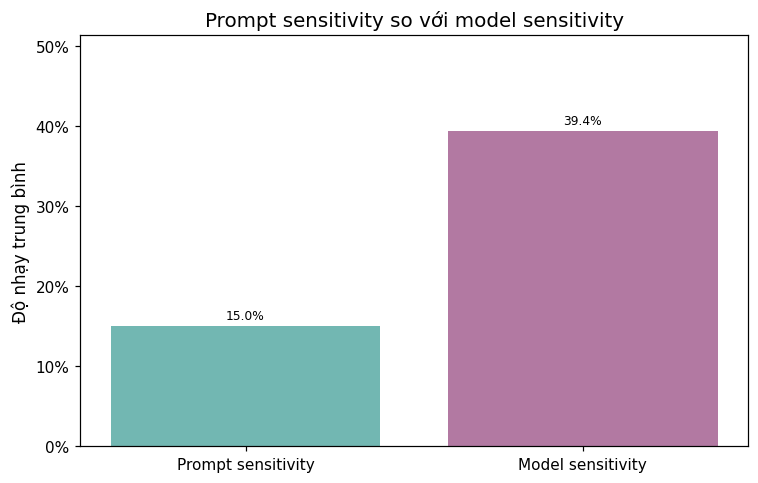

Kết quả nhạy với **model** hơn: độ nhạy tương ứng là **39.4%**, so với **15.0%** của yếu tố còn lại. Khoảng cách giữa hai độ nhạy là **+24.4 điểm %**.

In [40]:
prompt_sensitivity = delta_model_method.abs().stack().mean()

model_spread_cells = (
    df.groupby(["prompt_variant", "method", "model"], observed=True)["success"]
    .mean()
    .unstack("model")
    .reindex(columns=MODEL_ORDER)
)
model_ranges = model_spread_cells.max(axis=1) - model_spread_cells.min(axis=1)
model_sensitivity = model_ranges.mean()

sensitivity_table = pd.DataFrame({
    "sensitivity": [prompt_sensitivity, model_sensitivity],
}, index=["Prompt sensitivity", "Model sensitivity"])
display(viz.style_sensitivity(sensitivity_table))

fig = viz.plot_sensitivity(sensitivity_table)
plt.show()

dominant_sensitivity = (
    "model" if model_sensitivity > prompt_sensitivity else "prompt"
)
dominant_value = max(model_sensitivity, prompt_sensitivity)
weaker_value = min(model_sensitivity, prompt_sensitivity)
display(Markdown(
    f"Kết quả nhạy với **{dominant_sensitivity}** hơn: độ nhạy tương ứng là "
    f"**{dominant_value:.1%}**, so với **{weaker_value:.1%}** của yếu tố còn lại. "
    f"Khoảng cách giữa hai độ nhạy là "
    f"**{viz.pp(dominant_value - weaker_value)}**."
))


## 6. Difficulty scaling

Ba panel tương ứng ba model. Mỗi panel có bốn đường `basic/detailed × llm_only/llm_planner`,
đi từ easy đến hard.


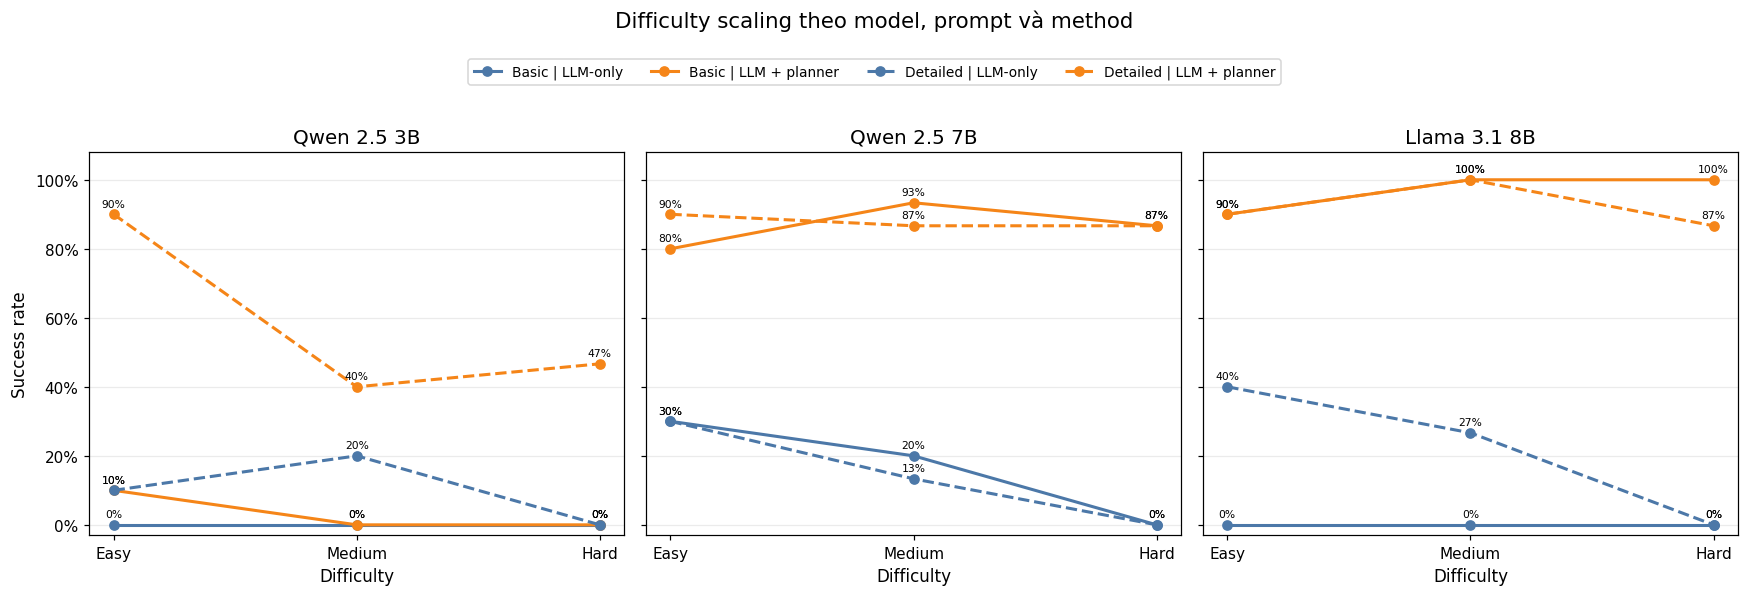

Cấu hình giảm mạnh nhất từ easy xuống hard là **Qwen 2.5 3B | Detailed | LLM + planner**, giảm **+43.3 điểm %**. Riêng trên hard, Detailed thay đổi success rate trung bình **+5.6 điểm %** so với Basic.

In [41]:
difficulty_rates = (
    df.groupby(
        ["model", "prompt_variant", "method", "difficulty"],
        observed=True,
    )["success"]
    .mean()
    .reindex(
        pd.MultiIndex.from_product(
            [MODEL_ORDER, PROMPT_ORDER, METHOD_ORDER, DIFFICULTY_ORDER],
            names=["model", "prompt_variant", "method", "difficulty"],
        )
    )
)

fig = viz.plot_difficulty_scaling(difficulty_rates)
plt.show()

difficulty_wide = difficulty_rates.unstack("difficulty")
easy_to_hard_drop = difficulty_wide["easy"] - difficulty_wide["hard"]
steepest_config = easy_to_hard_drop.idxmax()

hard_prompt_rates = (
    df[df["difficulty"] == "hard"]
    .groupby("prompt_variant", observed=True)["success"]
    .mean()
    .reindex(PROMPT_ORDER)
)
hard_prompt_delta = hard_prompt_rates["detailed"] - hard_prompt_rates["basic"]

display(Markdown(
    f"Cấu hình giảm mạnh nhất từ easy xuống hard là "
    f"**{MODEL_LABELS[steepest_config[0]]} | "
    f"{PROMPT_LABELS[steepest_config[1]]} | "
    f"{METHOD_LABELS[steepest_config[2]]}**, "
    f"giảm **{viz.pp(easy_to_hard_drop.max())}**. "
    f"Riêng trên hard, Detailed thay đổi success rate trung bình "
    f"**{viz.pp(hard_prompt_delta)}** so với Basic."
))


## 7. Phân rã pipeline - funnel

Các phần trước cho biết success rate khác nhau giữa các cấu hình; phần này truy ngược *vì sao* bằng cách phân rã pipeline thành từng stage và đo tỷ lệ bài vượt qua mỗi stage (trên tổng số bài của cấu hình). Độ tụt giữa hai stage liền nhau cho biết phần lớn thất bại rơi vào khâu nào — parse JSON, chạy planner, hay đạt goal — và prompt/model can thiệp vào đúng khâu đó ra sao. Hai method được vẽ riêng vì chuỗi stage của chúng khác nhau: `llm_planner` đi qua bước symbolic planner, còn `llm_only` thì không, nên cột `planner_success` chỉ áp dụng cho nhánh planner.


### 7a. Funnel của `llm_planner`

Chuỗi stage: `parse_success → planner_success → plan_valid → goal_achieved`.


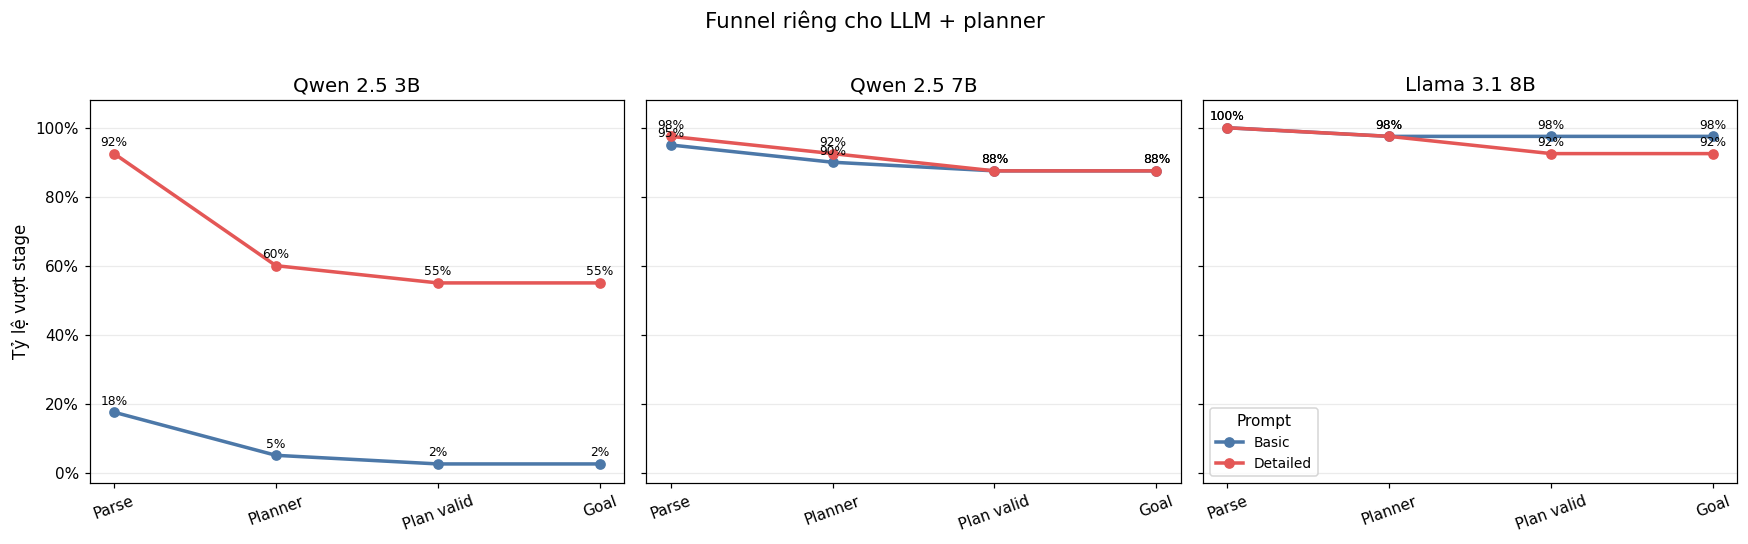

Trung bình trên ba model, stage được Detailed cải thiện nhiều nhất trong pipeline planner là **`parse_success` (+25.8 điểm %)**. Các stage phía sau phản ánh cả chất lượng parse lẫn khả năng planner tìm và thực thi plan hợp lệ.

In [42]:
PLANNER_STAGES = [
    "parse_success",
    "planner_success",
    "plan_valid",
    "goal_achieved",
]
planner_funnel = (
    df[df["method"] == "llm_planner"]
    .groupby(["model", "prompt_variant"], observed=True)[PLANNER_STAGES]
    .mean()
    .reindex(full_config_index)
)

display(
    viz.style_percent_table(
        planner_funnel,
        "Funnel LLM + planner theo model × prompt",
    )
)

fig = viz.plot_funnel(
    planner_funnel,
    stages=PLANNER_STAGES,
    stage_labels=["Parse", "Planner", "Plan valid", "Goal"],
    title="Funnel riêng cho LLM + planner",
    label_rotation=20,
)
plt.show()

planner_delta_by_stage = (
    planner_funnel.xs("detailed", level="prompt_variant")
    - planner_funnel.xs("basic", level="prompt_variant")
)
largest_planner_stage = planner_delta_by_stage.mean(axis=0).idxmax()
display(Markdown(
    f"Trung bình trên ba model, stage được Detailed cải thiện nhiều nhất "
    f"trong pipeline planner là **`{largest_planner_stage}` "
    f"({viz.pp(planner_delta_by_stage.mean(axis=0)[largest_planner_stage])})**. "
    "Các stage phía sau phản ánh cả chất lượng parse lẫn khả năng planner "
    "tìm và thực thi plan hợp lệ."
))


### 7b. Funnel của `llm_only`

Chuỗi đúng cho baseline này là `parse_success → plan_valid → goal_achieved`; hoàn toàn bỏ `planner_success`.


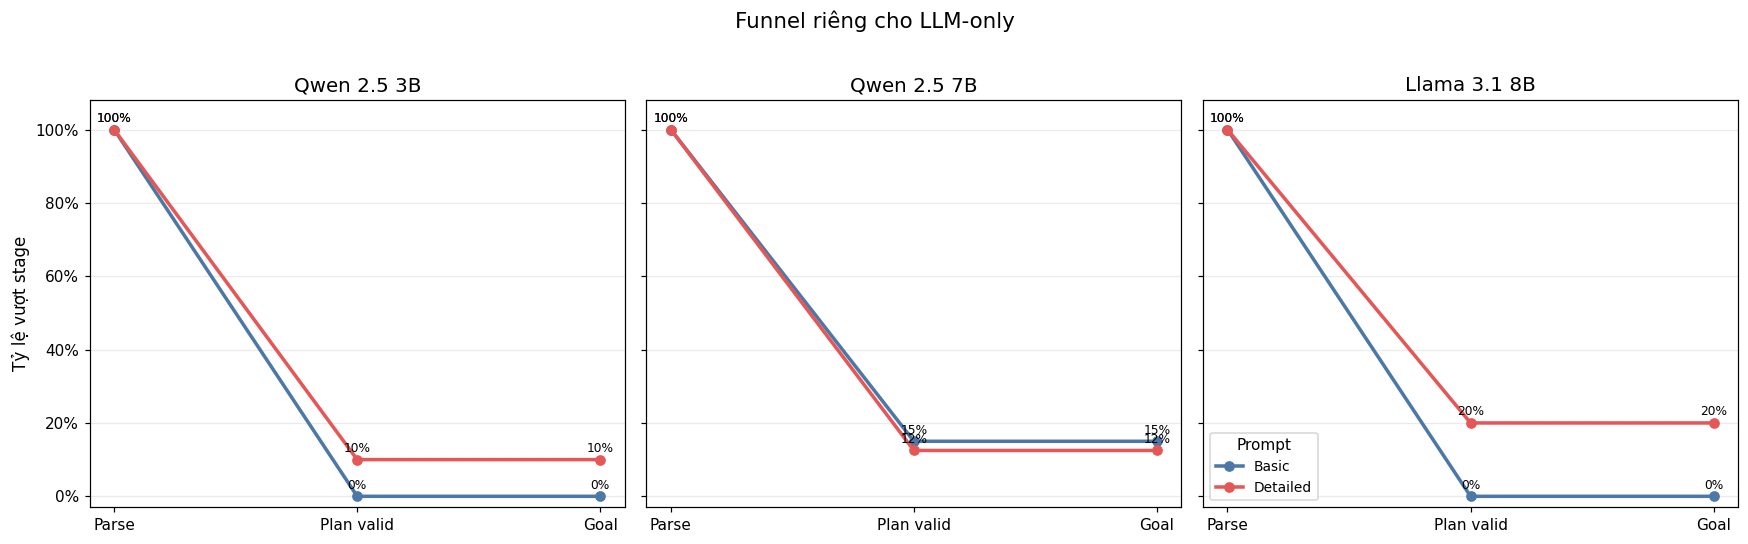

Trong LLM-only, stage có delta Detailed trung bình lớn nhất là **`plan_valid` (+9.2 điểm %)**. Khoảng rơi từ Parse xuống Plan valid đo trực tiếp mức LLM sinh action có đúng precondition/effect hay không.

In [43]:
LLM_ONLY_STAGES = ["parse_success", "plan_valid", "goal_achieved"]
llm_only_funnel = (
    df[df["method"] == "llm_only"]
    .groupby(["model", "prompt_variant"], observed=True)[LLM_ONLY_STAGES]
    .mean()
    .reindex(full_config_index)
)

display(
    viz.style_percent_table(
        llm_only_funnel,
        "Funnel LLM-only theo model × prompt",
    )
)

fig = viz.plot_funnel(
    llm_only_funnel,
    stages=LLM_ONLY_STAGES,
    stage_labels=["Parse", "Plan valid", "Goal"],
    title="Funnel riêng cho LLM-only",
)
plt.show()

llm_only_delta_by_stage = (
    llm_only_funnel.xs("detailed", level="prompt_variant")
    - llm_only_funnel.xs("basic", level="prompt_variant")
)
largest_llm_only_stage = llm_only_delta_by_stage.mean(axis=0).idxmax()
display(Markdown(
    f"Trong LLM-only, stage có delta Detailed trung bình lớn nhất là "
    f"**`{largest_llm_only_stage}` "
    f"({viz.pp(llm_only_delta_by_stage.mean(axis=0)[largest_llm_only_stage])})**. "
    "Khoảng rơi từ Parse xuống Plan valid đo trực tiếp mức LLM sinh action "
    "có đúng precondition/effect hay không."
))


## 8. Error analysis theo cấu hình

`error_type` được chuẩn hóa bằng phần đứng trước dấu `:`. Phân tích chỉ xét các lần chạy thất bại;
lỗi trống được gán `unspecified_failure`. Crosstab dùng đầy đủ `model × prompt × method`.


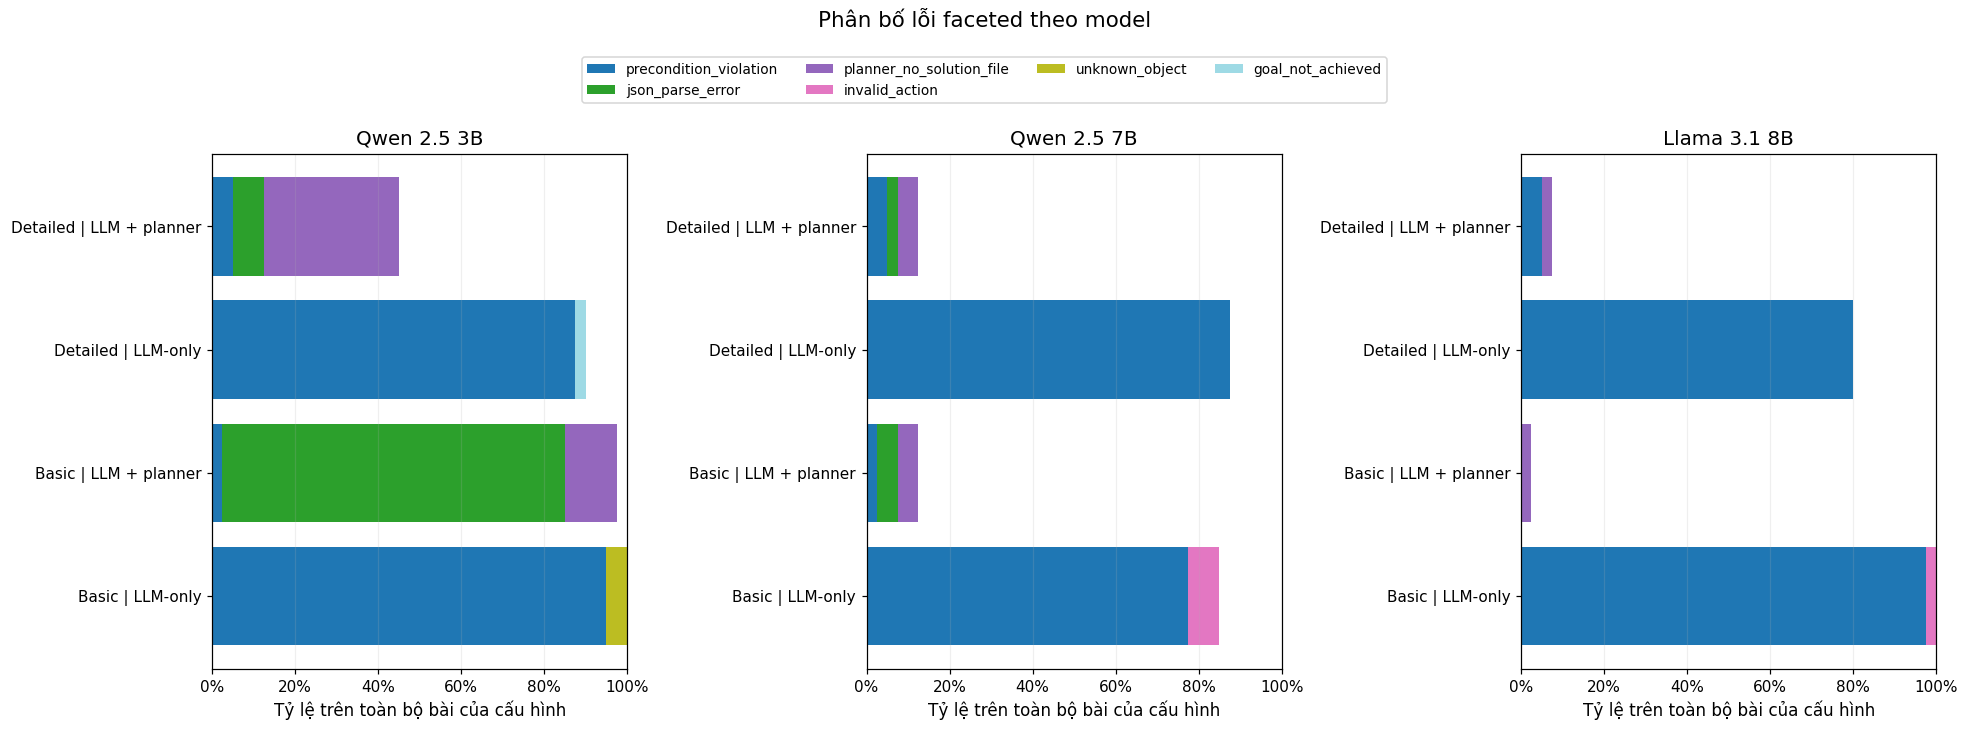

Chuyển dịch giảm mạnh nhất khi dùng Detailed là **`json_parse_error`** ở **Qwen 2.5 3B | LLM + planner**, với thay đổi **-75.0 điểm %**. Chuyển dịch tăng mạnh nhất là **`planner_no_solution_file`** ở **Qwen 2.5 3B | LLM + planner**, với thay đổi **+20.0 điểm %**.

In [44]:
raw_error = df["error_type"].fillna("").astype(str).str.strip()
normalized_error = raw_error.str.split(":", n=1).str[0].str.strip()
df["error_class"] = normalized_error.replace("", "unspecified_failure")

success_mask = df["success"].fillna(False).astype(bool)
failed = df.loc[~success_mask].copy()

full_error_index = pd.MultiIndex.from_product(
    [MODEL_ORDER, PROMPT_ORDER, METHOD_ORDER],
    names=["model", "prompt_variant", "method"],
)
error_counts = (
    pd.crosstab(
        [failed["model"], failed["prompt_variant"], failed["method"]],
        failed["error_class"],
    )
    .reindex(full_error_index, fill_value=0)
)
error_counts = error_counts.reindex(
    columns=error_counts.sum(axis=0).sort_values(ascending=False).index
)

display(viz.style_error_counts(error_counts))

config_totals = (
    df.groupby(["model", "prompt_variant", "method"], observed=True)
    .size()
    .reindex(full_error_index)
)
error_incidence = error_counts.div(config_totals, axis=0).fillna(0)

fig = viz.plot_error_stacked(error_incidence)
plt.show()

error_delta_rows = []
for model in MODEL_ORDER:
    for method in METHOD_ORDER:
        basic_rates = error_incidence.loc[(model, "basic", method)]
        detailed_rates = error_incidence.loc[(model, "detailed", method)]
        for error_name in error_incidence.columns:
            error_delta_rows.append({
                "model": model,
                "method": method,
                "error_class": error_name,
                "delta": detailed_rates[error_name] - basic_rates[error_name],
            })

error_delta = pd.DataFrame(error_delta_rows)
biggest_reduction = error_delta.loc[error_delta["delta"].idxmin()]
biggest_increase = error_delta.loc[error_delta["delta"].idxmax()]

display(Markdown(
    f"Chuyển dịch giảm mạnh nhất khi dùng Detailed là "
    f"**`{biggest_reduction['error_class']}`** ở "
    f"**{MODEL_LABELS[biggest_reduction['model']]} | "
    f"{METHOD_LABELS[biggest_reduction['method']]}**, "
    f"với thay đổi **{viz.pp(biggest_reduction['delta'])}**. "
    f"Chuyển dịch tăng mạnh nhất là **`{biggest_increase['error_class']}`** "
    f"ở **{MODEL_LABELS[biggest_increase['model']]} | "
    f"{METHOD_LABELS[biggest_increase['method']]}**, "
    f"với thay đổi **{viz.pp(biggest_increase['delta'])}**."
))


## 9. Kết luận


In [45]:
config_rates = (
    df.groupby(["model", "prompt_variant", "method"], observed=True)["success"]
    .mean()
)
best_config = config_rates.idxmax()
best_rate = config_rates.max()

prompt_change = prompt_overall["detailed"] - prompt_overall["basic"]
prompt_direction = "tăng" if prompt_change >= 0 else "giảm"

most_helped_model = delta_model.idxmax()
most_helped_delta = delta_model[most_helped_model]

difficulty_prompt_rates = (
    df.groupby(["difficulty", "prompt_variant"], observed=True)["success"]
    .mean()
    .unstack("prompt_variant")
    .reindex(index=DIFFICULTY_ORDER, columns=PROMPT_ORDER)
)
difficulty_prompt_delta = (
    difficulty_prompt_rates["detailed"] - difficulty_prompt_rates["basic"]
)
largest_gap_difficulty = difficulty_prompt_delta.abs().idxmax()
largest_gap_value = difficulty_prompt_delta[largest_gap_difficulty]

method_effect_size = (
    df.groupby("method", observed=True)["success"].mean().max()
    - df.groupby("method", observed=True)["success"].mean().min()
)
model_effect_size = (
    df.groupby("model", observed=True)["success"].mean().max()
    - df.groupby("model", observed=True)["success"].mean().min()
)
prompt_effect_size = abs(prompt_change)

method_interaction_range = delta_method.max() - delta_method.min()
model_interaction_range = delta_model.max() - delta_model.min()

all_three_vary = all(
    value > 0
    for value in [method_effect_size, model_effect_size, prompt_effect_size]
)
dependency_statement = (
    "Trong dữ liệu thực nghiệm này, success phụ thuộc cả 3 yếu tố "
    "method/model/prompt."
    if all_three_vary
    else "Trong dữ liệu hiện có, ít nhất một main effect bằng 0; "
    "cần tránh khẳng định cả ba yếu tố đều thay đổi success."
)

display(Markdown(f'''
### Kết luận chính

- **Cấu hình tốt nhất:** {MODEL_LABELS[best_config[0]]} ×
  {PROMPT_LABELS[best_config[1]]} × {METHOD_LABELS[best_config[2]]},
  với success rate **{best_rate:.1%}**.
- **Ảnh hưởng trung bình của prompt:** Detailed làm success rate {prompt_direction}
  **{abs(prompt_change) * 100:.1f} điểm %** so với Basic
  ({prompt_overall['basic']:.1%} → {prompt_overall['detailed']:.1%}).
- **Model hưởng lợi nhiều nhất từ Detailed:** {MODEL_LABELS[most_helped_model]},
  delta **{viz.pp(most_helped_delta)}**.
- **Difficulty có prompt gap lớn nhất:** `{largest_gap_difficulty}`,
  Detailed − Basic = **{viz.pp(largest_gap_value)}**.
- **Main-effect spread:** method **{method_effect_size:.1%}**,
  model **{model_effect_size:.1%}**, prompt **{prompt_effect_size:.1%}**.
- **Interaction:** prompt delta thay đổi **{method_interaction_range:.1%}**
  giữa các method và **{model_interaction_range:.1%}** giữa các model.

**{dependency_statement}** Bằng chứng định lượng là cả ba main-effect spread
đều khác 0, đồng thời prompt delta không đồng nhất giữa method và model.
Do đó không nên đánh giá một prompt, model hoặc pipeline tách rời hai yếu tố còn lại.
'''))



### Kết luận chính

- **Cấu hình tốt nhất:** Llama 3.1 8B ×
  Basic × LLM + planner,
  với success rate **97.5%**.
- **Ảnh hưởng trung bình của prompt:** Detailed làm success rate tăng
  **12.5 điểm %** so với Basic
  (33.8% → 46.2%).
- **Model hưởng lợi nhiều nhất từ Detailed:** Qwen 2.5 3B,
  delta **+31.2 điểm %**.
- **Difficulty có prompt gap lớn nhất:** `easy`,
  Detailed − Basic = **+23.3 điểm %**.
- **Main-effect spread:** method **60.8%**,
  model **35.6%**, prompt **12.5%**.
- **Interaction:** prompt delta thay đổi **6.7%**
  giữa các method và **32.5%** giữa các model.

**Trong dữ liệu thực nghiệm này, success phụ thuộc cả 3 yếu tố method/model/prompt.** Bằng chứng định lượng là cả ba main-effect spread
đều khác 0, đồng thời prompt delta không đồng nhất giữa method và model.
Do đó không nên đánh giá một prompt, model hoặc pipeline tách rời hai yếu tố còn lại.
